# Metrics
Build the three suggested network models and save your data. A summary function is provided to save the average of the thirty results.

In [67]:
import sys
sys.path.insert(0, "..")

import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from collections import Counter
from methods.similarity import common_aisles
from process.dataset import Problem
from process.graph import Graph
from typing import Any

## Auxiliary functions
Function to calculate metrics and function to summarize the results.

In [3]:
def calculate_metrics(g: ig.Graph) -> dict[str, Any]:
    components = g.connected_components()
    sizes = components.sizes()
    bigger_component = max(sizes)

    # Largest component by length and diameter.
    giant = components.giant()

    degrees = g.degree()
    return {
        "nodes": g.vcount(),
        "edges": g.ecount(),
        "density": g.density(),
        "mean_degree": np.mean(degrees),
        "std_degree": np.std(degrees),
        "clustering": g.transitivity_avglocal_undirected(),
        "avg_path_length": giant.average_path_length(),
        "diameter": giant.diameter(),
        "components": len(sizes),
        "largest_component": bigger_component,
        "isolated_nodes": sum(k == 0 for k in degrees)
    }

In [55]:
def resume_models(
    instance: int,
    df_er: pd.DataFrame,
    df_ws: pd.DataFrame,
    df_ba: pd.DataFrame,
    df_bl: pd.DataFrame
) -> pd.DataFrame:
    results = []

    for model, df in [
        ("ER", df_er),
        ("WS", df_ws),
        ("BA", df_ba),
        ("BL", df_bl)
    ]:
        row = {
            "instance": instance,
            "model": model
        }

        metrics = [
            "nodes",
            "edges",
            "density",
            "mean_degree",
            "std_degree",
            "clustering",
            "avg_path_length",
            "diameter",
            "components",
            "largest_component",
            "isolated_nodes"
        ]

        for metric in metrics:
            if model != "BL":
                mean = df[metric].mean()
                std = df[metric].std()

                row[metric] = f"{mean:.4f} ± {std:.4f}"
            else:
                row[metric] = f"{df[metric][0]:.4f} ± {0:.4f}"

        results.append(row)

    return pd.DataFrame(results)

## Degree distribution

In [68]:
def degree_distribution(g: ig.Graph):
    degrees = g.degree()
    c = Counter(degrees)
    N = g.vcount()

    return {
        k: v / N
        for k, v in c.items()
    }

In [73]:
def mean_degree_distribution(grafos: list[ig.Graph]):
    dist = [degree_distribution(g) for g in grafos]
    degrees = sorted(
        set().union(*[d.keys() for d in dist])
    )

    mean = {}

    for k in degrees:
        val = [
            d.get(k, 0)
            for d in dist
        ]

        mean[k] = np.mean(val)

    return mean

## Generate models
Functions for generating the models.

In [69]:
def generate_er(
    N: int,
    L: int,
    n: int = 30
) -> tuple[pd.DataFrame, list[ig.Graph]]:
    results = []
    graphs = []

    for i in range(1, n + 1):
        g = ig.Graph.Erdos_Renyi(
            n=N,
            m=L,
            directed=False,
            loops=False
        )

        metrics = calculate_metrics(g)
        metrics["model"] = "ER"
        metrics["replicate"] = i

        results.append(metrics)
        graphs.append(g)

    return pd.DataFrame(results), graphs

In [70]:
def generate_ws(
    N: int,
    L: int,
    n: int = 30,
    p: float = 0.1
) -> tuple[pd.DataFrame, list[ig.Graph]]:
    k = round((2 * L) / N)
    if k % 2 != 0:
        k += 1

    k = min(k, N - 1)
    if k % 2 != 0:
        k -= 1

    results = []
    graphs = []

    for i in range(1, n + 1):
        g = ig.Graph.Watts_Strogatz(
            dim=1,
            size=N,
            nei=k // 2,
            p=p
        )

        metrics = calculate_metrics(g)
        metrics["model"] = "WS"
        metrics["replicate"] = i

        results.append(metrics)
        graphs.append(g)

    return pd.DataFrame(results), graphs

In [71]:
def generate_ba(
    N: int,
    L: int,
    n: int = 30
) -> tuple[pd.DataFrame, list[ig.Graph]]:
    m = round(L / N)
    m = max(1, m)
    m = min(m, N - 1)

    results = []
    graphs = []

    for i in range(1, n + 1):
        g = ig.Graph.Barabasi(
            n=N,
            m=m,
            directed=False
        )

        metrics = calculate_metrics(g)
        metrics["model"] = "BA"
        metrics["replicate"] = i

        results.append(metrics)
        graphs.append(g)

    return pd.DataFrame(results), graphs

## Evaluate models

In [88]:
instance = input("Enter the instance name (e.g., 'instance_0001.txt'): ")
problem = Problem("../../dataset/" + instance)
graph = Graph(problem, common_aisles)

In [89]:
N = graph.g.vcount()
L = graph.g.ecount()

df_er, er = generate_er(N, L)
df_ws, ws = generate_ws(N, L)
df_ba, ba = generate_ba(N, L)

baseline = calculate_metrics(graph.g)
baseline["model"] = "BL"
baseline["replicate"] = 1
df_baseline = pd.DataFrame([baseline])

In [90]:
resume = resume_models(
    int(instance[9:-4]),
    df_er,
    df_ws,
    df_ba,
    df_baseline
)

In [ ]:
resume.to_csv(
    "../../results/models_metrics.csv",
    mode="a",
    header=not os.path.exists("../../results/models_metrics.csv"),
    index=False
)

### Degree distribution

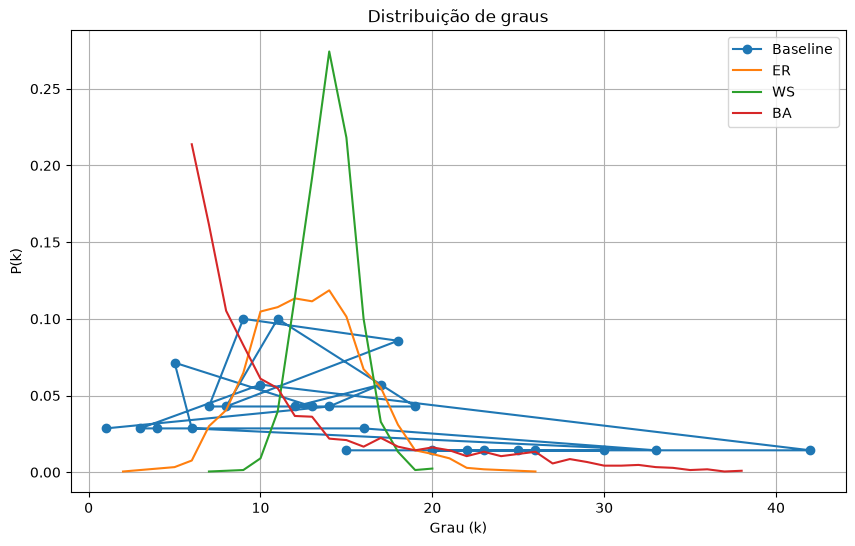

In [92]:
dist_er = mean_degree_distribution(er)
dist_ws = mean_degree_distribution(ws)
dist_ba = mean_degree_distribution(ba)
dist_bl = degree_distribution(graph.g)

plt.figure(figsize=(10, 6))

plt.plot(
    list(dist_bl.keys()),
    list(dist_bl.values()),
    marker='o',
    label='Baseline'
)

plt.plot(
    list(dist_er.keys()),
    list(dist_er.values()),
    label='ER'
)

plt.plot(
    list(dist_ws.keys()),
    list(dist_ws.values()),
    label='WS'
)

plt.plot(
    list(dist_ba.keys()),
    list(dist_ba.values()),
    label='BA'
)

plt.xlabel("Grau (k)")
plt.ylabel("P(k)")
plt.title("Distribuição de graus")
plt.legend()
plt.grid(True)
plt.show()